In [25]:
import pandas as pd
df = pd.read_csv("../data/clean_titanic_dataset.csv")
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,initials
0,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,0,S,Mr
1,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,1,C,Mrs
2,1.0,3.0,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,0,S,Miss
3,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,1,S,Mrs
4,0.0,3.0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,0,S,Mr


# Data Encoding

Data Encoding is a technique that is used to convert categorical columns into numerical ones so that they can be fitted by machine learning models which only take numerical data. It is an important pre-processing step in a machine-learning project.

#  Nominal and Ordinal Data

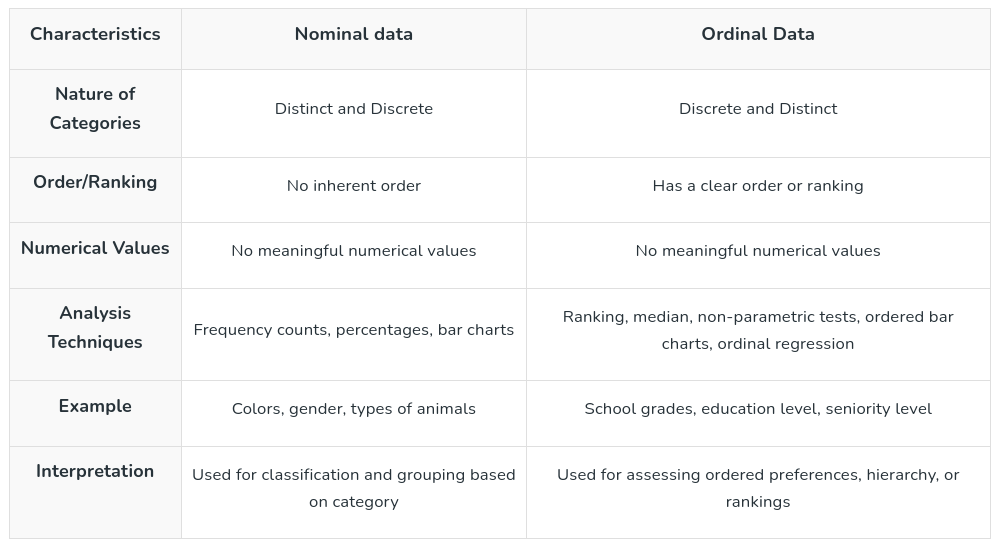

In [26]:
# Nominal Data  -> data without natural order
df.Sex

0        male
1      female
2      female
3      female
4        male
        ...  
884      male
885    female
886    female
887      male
888      male
Name: Sex, Length: 889, dtype: str

# One- Hot Encoding

One-hot encoding is a data preprocessing technique that turns text or categorical values into binary numbers (0s and 1s) so machine learning models can understand them

In [27]:
# pandas

pd.get_dummies(
    df,
    columns= ['Sex'],
    dtype= int
).head(5)

,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,initials,Sex_female,Sex_male
0,0.0,3.0,"Braund, Mr. Owen Harris",22.0,1.0,0.0,A/5 21171,7.2500,0,S,Mr,0,1
1,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1.0,0.0,PC 17599,71.2833,1,C,Mrs,1,0
2,1.0,3.0,"Heikkinen, Miss. Laina",26.0,0.0,0.0,STON/O2. 3101282,7.9250,0,S,Miss,1,0
3,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1.0,0.0,113803,53.1000,1,S,Mrs,1,0
4,0.0,3.0,"Allen, Mr. William Henry",35.0,0.0,0.0,373450,8.0500,0,S,Mr,0,1


In [28]:
import sklearn
sklearn.show_versions()


System:
    python: 3.14.5 (v3.14.5:5607950ef23, May 10 2026, 07:38:09) [Clang 21.0.0 (clang-2100.0.123.102)]
executable: /Users/over/Documents/Code/Data Science & Machine Learning/.venv/bin/python
   machine: macOS-26.6.2-arm64-arm-64bit-Mach-O

Python dependencies:
      sklearn: 1.9.0
          pip: 26.2.1
   setuptools: None
        numpy: 2.5.2
        scipy: 1.18.1
       Cython: None
       pandas: 3.0.5
   matplotlib: 3.11.1
       joblib: 1.6.0
threadpoolctl: 3.6.0
     narwhals: 2.25.0

Built with OpenMP: True

threadpoolctl info:
       user_api: openmp
   internal_api: openmp
    num_threads: 8
         prefix: libomp
       filepath: /Users/over/Documents/Code/Data Science & Machine Learning/.venv/lib/python3.14/site-packages/sklearn/.dylibs/libomp.dylib
        version: None


In [29]:
# sklearn

from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder(
    sparse_output= False
)

In [30]:
one_hot_encoder.fit_transform(
    df[["Sex"]]
)

array([[0., 1.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [0., 1.],
       [0., 1.]], shape=(889, 2))

In [31]:
one_hot_encoder.categories_

[array(['female', 'male'], dtype=object)]

In [32]:
one_hot_encoder.inverse_transform([
    [0, 1],
    [1, 0],
    [1, 0]
])

array([['male'],
       ['female'],
       ['female']], dtype=object)

In [33]:
# example Ordinal Data  -> data natural order
df.Embarked.value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [34]:
# Pandas 
df['encoded_embarked'],rule = pd.factorize(df.Embarked)

In [35]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,initials,encoded_embarked
0,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,0,S,Mr,0
1,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,1,C,Mrs,1
2,1.0,3.0,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,0,S,Miss,0
3,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,1,S,Mrs,0
4,0.0,3.0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,0,S,Mr,0


In [36]:
df.encoded_embarked.value_counts()

encoded_embarked
0    644
1    168
2     77
Name: count, dtype: int64

In [37]:
# Sklean

from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
encoded_result = ordinal_encoder.fit_transform(
    df[['Embarked']]
)
encoded_result

array([[2.],
       [0.],
       [2.],
       [2.],
       [2.],
       [1.],
       [2.],
       [2.],
       [2.],
       [0.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [1.],
       [2.],
       [2.],
       [0.],
       [2.],
       [2.],
       [1.],
       [2.],
       [2.],
       [2.],
       [0.],
       [2.],
       [1.],
       [2.],
       [0.],
       [0.],
       [1.],
       [2.],
       [0.],
       [2.],
       [0.],
       [2.],
       [2.],
       [0.],
       [2.],
       [2.],
       [0.],
       [0.],
       [1.],
       [2.],
       [1.],
       [1.],
       [0.],
       [2.],
       [2.],
       [2.],
       [0.],
       [2.],
       [0.],
       [2.],
       [2.],
       [0.],
       [2.],
       [2.],
       [0.],
       [2.],
       [2.],
       [0.],
       [0.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [0.],
       [2.],
       [2.],
       [2.],
       [2.],

In [38]:
ordinal_encoder.categories_

[array(['C', 'Q', 'S'], dtype=object)]

In [39]:
ordinal_encoder.inverse_transform(
    [[1],
     [2],
     [0],
     [1]]
)

array([['Q'],
       ['S'],
       ['C'],
       ['Q']], dtype=object)

In [40]:
final_df = df.drop(
["Name", "Ticket", "initials", "encoded_embarked"],
axis= 1
)

In [41]:
onehot_encoder = OneHotEncoder(sparse_output= False)
ordinal_encoder = OrdinalEncoder()

In [42]:
age_embarked_encoded = onehot_encoder.fit_transform(
    df[["Sex"]]
)
pclass_encoded = ordinal_encoder.fit_transform(
    final_df[["Pclass"]]
)

In [43]:
final_df = pd.get_dummies(
    final_df,
    columns=["Sex", "Embarked"],
    dtype= int
)

In [44]:
final_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.0,3.0,22.0,1.0,0.0,7.2500,0,0,1,0,0,1
1,1.0,1.0,38.0,1.0,0.0,71.2833,1,1,0,1,0,0
2,1.0,3.0,26.0,0.0,0.0,7.9250,0,1,0,0,0,1
3,1.0,1.0,35.0,1.0,0.0,53.1000,1,1,0,0,0,1
4,0.0,3.0,35.0,0.0,0.0,8.0500,0,0,1,0,0,1


In [45]:
part = "../data/encoded_titanic_dataset.csv"
final_df.to_csv(
    part,
    index= True
)